# E4 — Engine: OLLAMA vs LLAMA.cpp

## Pregunta de investigación

¿Qué engine proporciona mejor rendimiento y eficiencia?

## Hipótesis previa

LLAMA.cpp podría ofrecer mejor optimización que OLLAMA en RPi5.

## Configuración del experimento

| Parámetro | Valores |
|-----------|---------|
| Motores | OLLAMA vs LLAMA.cpp |
| Modelos | Múltiples (mismo modelo en ambos engines) |
| Total | Pares de runs |

In [1]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

from monitorviz.io import load_collection
from monitorviz.viz import setup_style

setup_style("talk")
warnings.filterwarnings("ignore", category=UserWarning, module="seaborn")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

# --- Carga de datos (E0-FAN, mismo dataset que E0) ---
_here = Path.cwd()
PROJECT_ROOT = _here.parent if _here.name == "notebooks" else _here
DATA_ROOT = PROJECT_ROOT / "data" / "tfg-data" / "E0-FAN"

assert DATA_ROOT.is_dir(), f"❌ No encontrado: {DATA_ROOT.resolve()}"

coll = load_collection(DATA_ROOT)
print(f"Runs cargados E4 (E0-FAN): {len(coll)}")

# --- Filtrado para 10 ---
summary = coll.summary_df()
hw_full = coll.hw_metrics_df()
pm_full = coll.prompt_metrics_df()

e4 = summary[
    (summary["test_type"] == "TYPE_1") &
    (summary["accelerator"] == False)
].copy()

ex = e4

print(f"\nRuns en 10_E4_engine: {ex.shape[0]}")
if len(ex) > 0:
    print(f"Configuraciones únicas: {ex.shape[0]} runs")
else:
    print("Sin datos disponibles para este experimento")

Runs cargados E4 (E0-FAN): 24

Runs en 10_E4_engine: 24
Configuraciones únicas: 24 runs


## Resumen ejecutivo

> TODO: Actualizar con resultados finales.

Placeholder: 3-5 frases resumiendo los hallazgos principales.

## Comparativa de métricas de inferencia

Throughput, latencia, TTFT, perplejidad por configuración.

In [2]:
# Tabla resumen
display_cols = [
    "model_label", "engine",
    "tokens_per_s_mean", "words_per_s_mean",
    "latency_ms_mean", "ttft_ms_mean",
    "perplexity_geomean",
]
cols = [c for c in display_cols if c in ex.columns]
if not ex.empty:
    display(ex[cols].round(3))
else:
    print("Sin datos para esta tabla")

,model_label,engine,tokens_per_s_mean,words_per_s_mean,latency_ms_mean,ttft_ms_mean,perplexity_geomean
0,ministral (O),OLLAMA,2.100,1.473,424964.275,20014.089,2.103
1,ministral (L),LLAMA,2.858,2.010,407140.417,3629.400,2.810
2,Llama-3.2-3B (O),OLLAMA,2.554,1.861,163999.251,12763.883,1.430
3,Llama-3.2-3B (L),LLAMA,2.384,1.740,850692.187,4291.243,2.286
4,Llama-3.2-1B (O),OLLAMA,6.830,5.137,60048.807,4603.280,1.654
5,Llama-3.2-1B (L),LLAMA,6.861,5.291,350077.805,1306.107,2.360
6,granite (O),OLLAMA,2.408,1.882,161774.734,20424.302,1.694
7,granite (L),LLAMA,2.781,2.148,143151.125,4423.324,2.854
8,gemma (O),OLLAMA,2.910,2.034,201334.289,12508.432,1.132
9,gemma (L),LLAMA,3.094,2.162,186211.320,5226.373,2.420


## Comparativa de hardware

Temperatura, potencia, throttling.

In [3]:
# Tabla hardware
if "temp_max_c" in ex.columns:
    hw_cols = [
        "model_label",
        "temp_max_c", "temp_mean_c",
        "power_mean_w", "power_max_w",
        "throttled_ratio",
    ]
    hw_cols = [c for c in hw_cols if c in ex.columns]
    if not ex.empty:
        display(ex[hw_cols].round(2))
else:
    print("Sin datos de hardware")

,model_label,temp_max_c,temp_mean_c,power_mean_w,power_max_w,throttled_ratio
0,ministral (O),96.35,92.30,5.15,9.01,0.99
1,ministral (L),95.80,91.47,4.87,9.68,1.00
2,Llama-3.2-3B (O),96.35,93.92,5.03,8.61,0.99
3,Llama-3.2-3B (L),96.35,92.95,4.85,9.57,1.00
4,Llama-3.2-1B (O),96.35,92.77,4.93,8.87,0.99
5,Llama-3.2-1B (L),95.80,93.05,4.78,9.10,1.00
6,granite (O),96.35,93.89,5.01,8.89,0.99
7,granite (L),95.80,93.35,4.94,9.61,1.00
8,gemma (O),96.35,93.58,4.95,8.86,0.99
9,gemma (L),95.80,93.03,4.86,9.36,1.00


## Timelines de temperatura y potencia

Small multiples con un subplot por modelo.

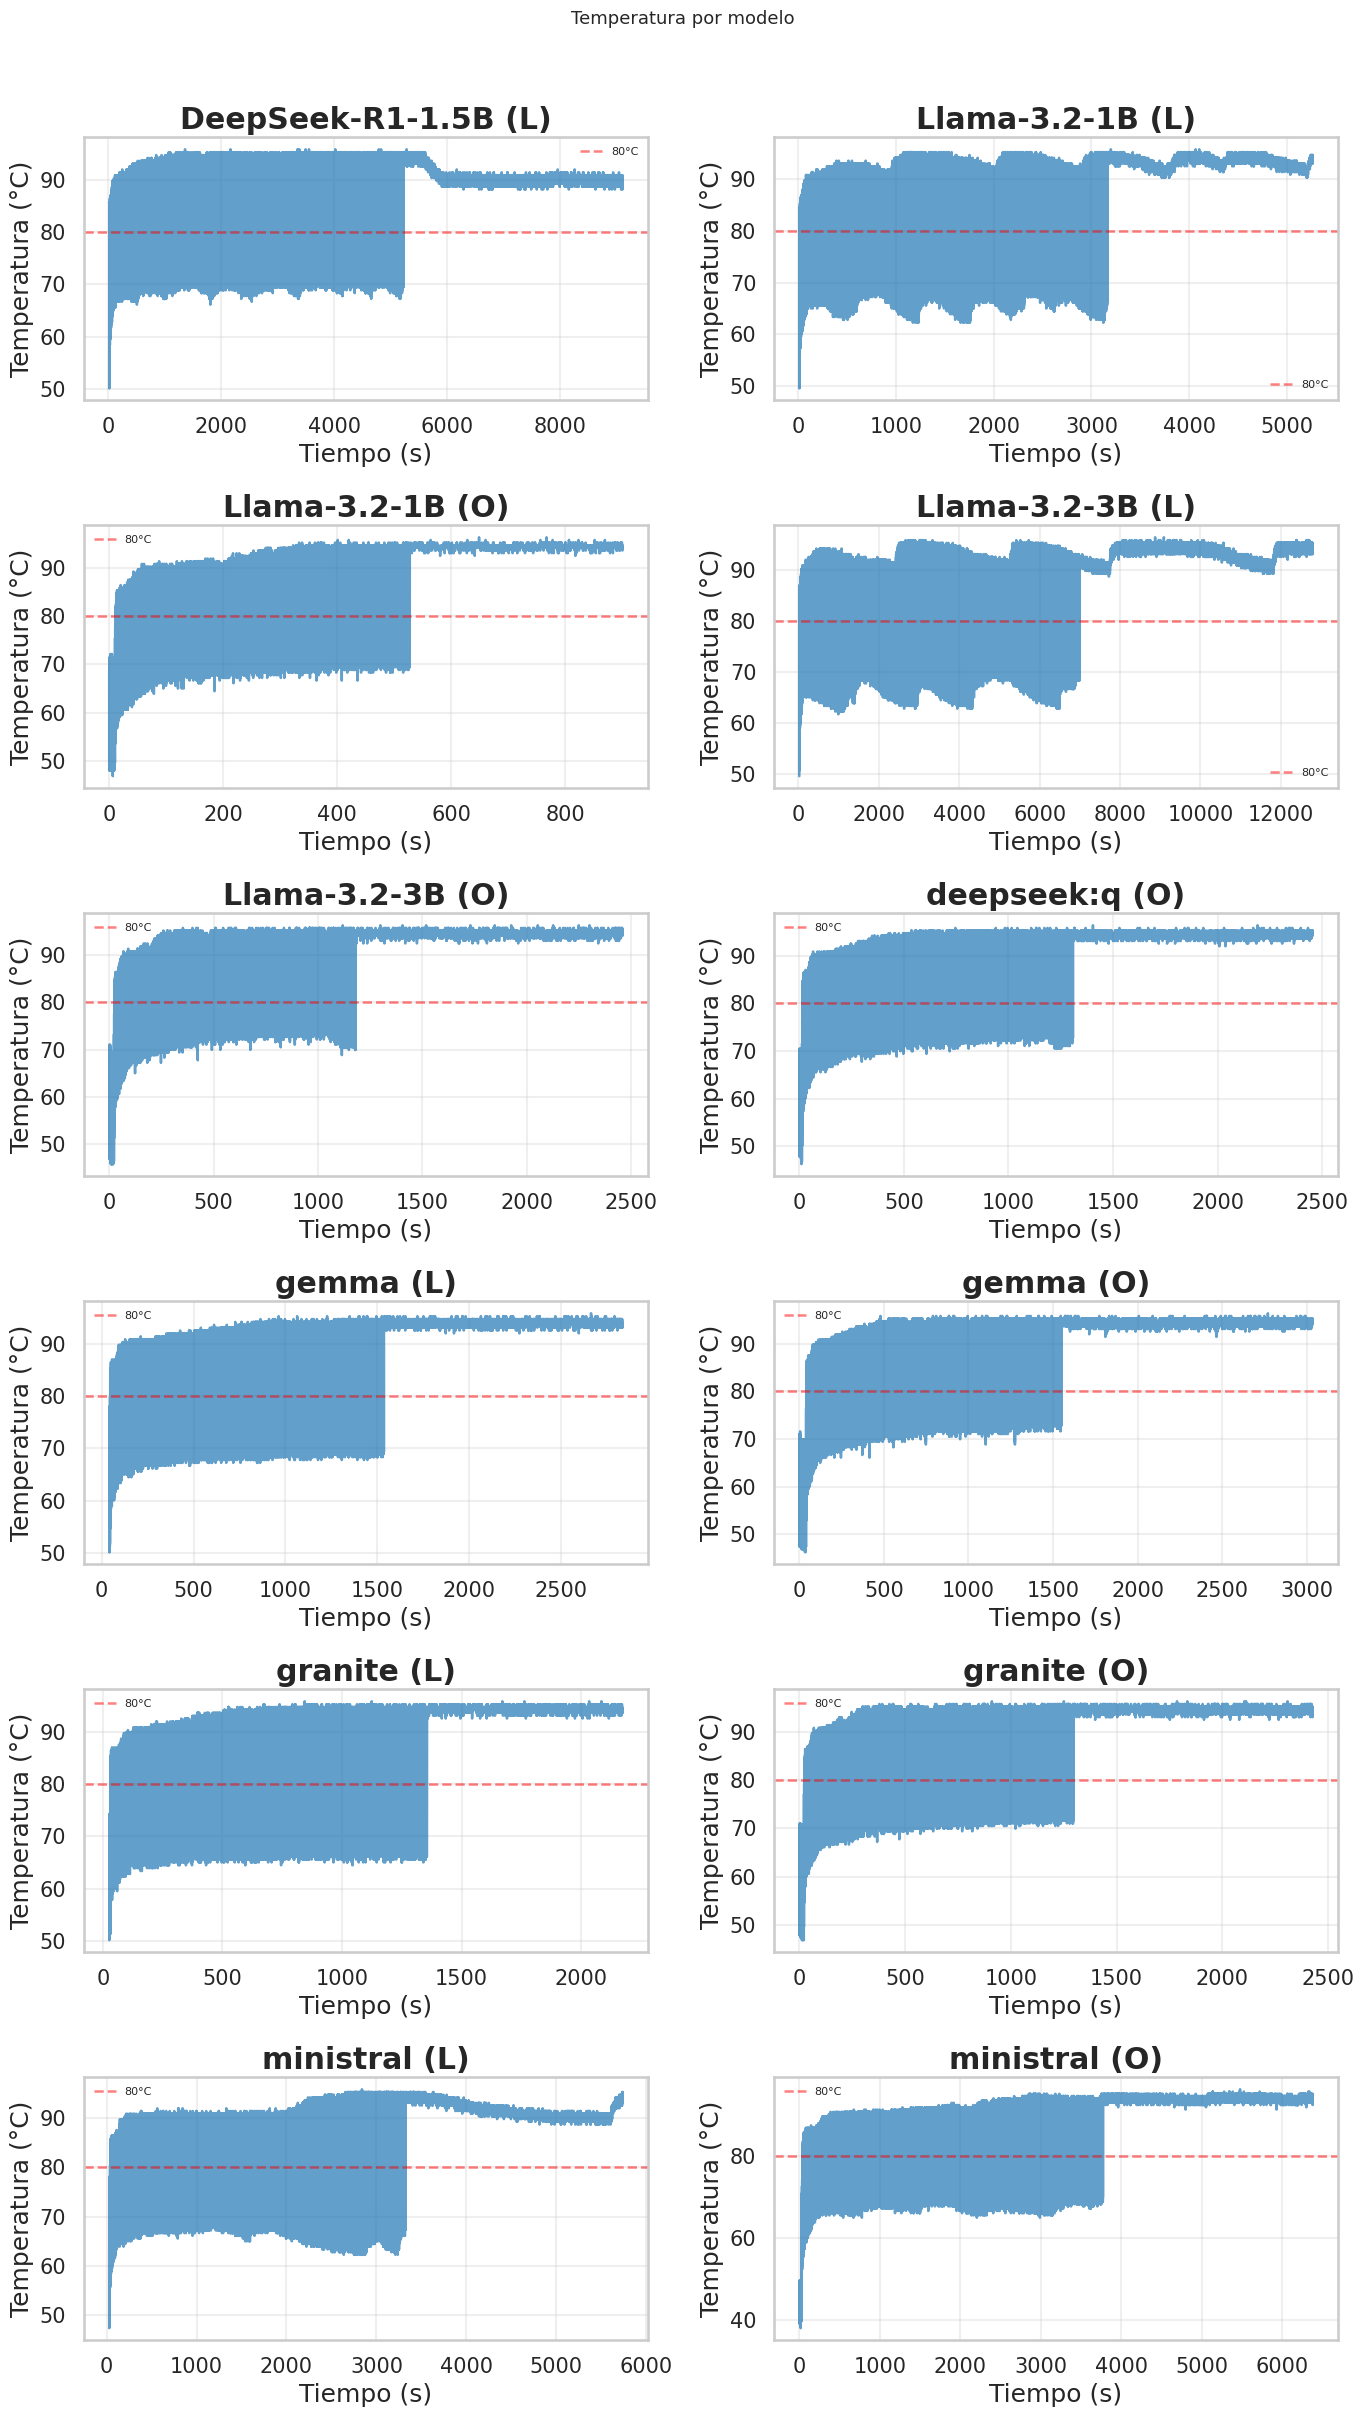

In [4]:

# Timelines de temperatura
hw_ex = hw_full[hw_full["run_id"].isin(ex["run_id"])]

if not hw_ex.empty:
    models = sorted(ex["model_label"].unique())
    ncols = 2
    nrows = (len(models) + 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4*nrows))
    if len(models) == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for ax, model in zip(axes, models):
        hw_m = hw_ex[hw_ex["model_label"] == model]
        if hw_m.empty:
            ax.text(0.5, 0.5, f"{model}\nSin datos", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
            continue
        sns.lineplot(data=hw_m, x="t_rel_s", y="temperature_c", ax=ax, alpha=0.7)
        ax.axhline(80, ls="--", color="red", alpha=0.5, label="80°C")
        ax.set_xlabel("Tiempo (s)")
        ax.set_ylabel("Temperatura (°C)")
        ax.set_title(f"{model}", fontweight="bold")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    for ax in axes[len(models):]:
        ax.set_visible(False)

    fig.suptitle("Temperatura por modelo", fontsize=13, y=1.01)
    fig.tight_layout()
    plt.show()
else:
    print("Sin datos de hardware")


## Distribución CPU y Memoria

/tmp/ipykernel_21110/1190418552.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_21110/1190418552.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


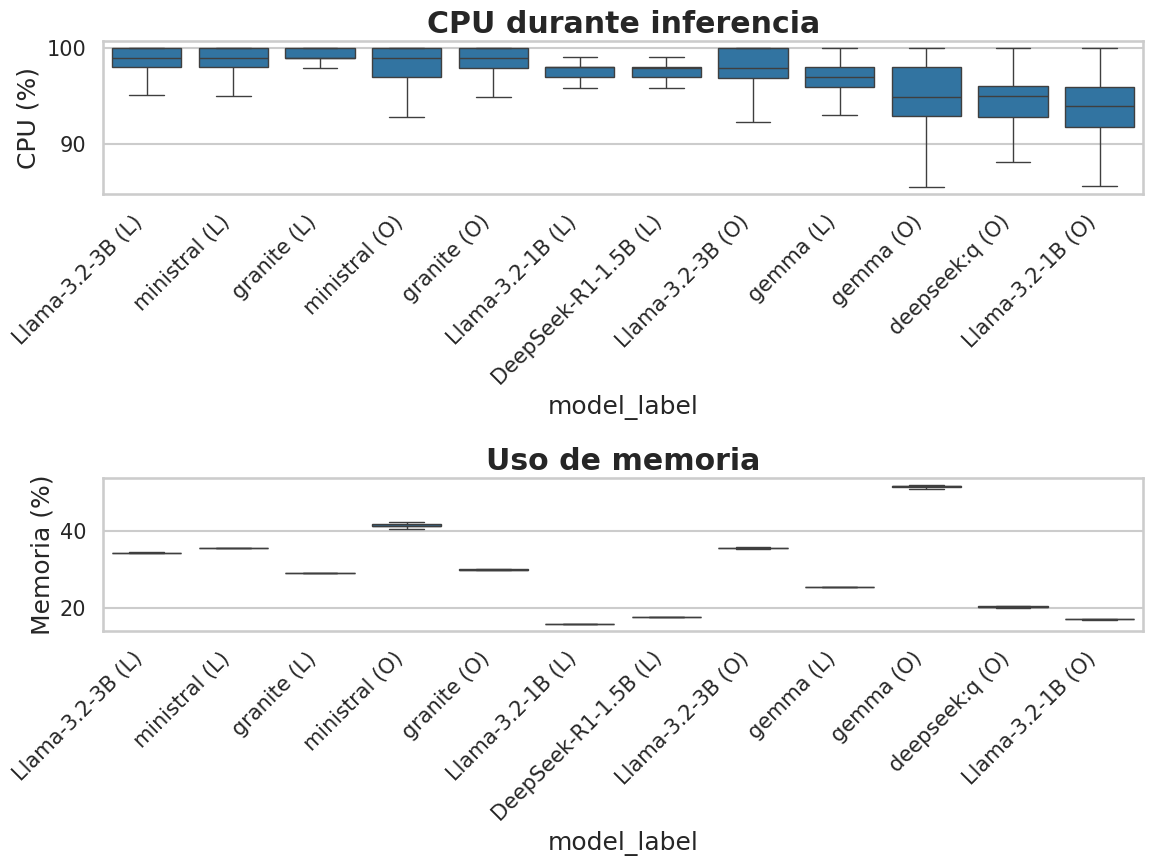

In [5]:
# Boxplot CPU y Memoria
hw_ex = hw_full[hw_full["run_id"].isin(ex["run_id"])]
if not hw_ex.empty:
    hw_inference = hw_ex[hw_ex["cpu_usage_pct"] > 50]
    fig, axes = plt.subplots(2, 1, figsize=(12, 9))
    order = hw_ex.groupby("model_label")["cpu_usage_pct"].median().sort_values(ascending=False).index

    sns.boxplot(data=hw_inference, x="model_label", y="cpu_usage_pct", order=order, showfliers=False, ax=axes[0])
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
    axes[0].set_ylabel("CPU (%)")
    axes[0].set_title("CPU durante inferencia")

    sns.boxplot(data=hw_ex, x="model_label", y="mem_pct", order=order, showfliers=False, ax=axes[1])
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
    axes[1].set_ylabel("Memoria (%)")
    axes[1].set_title("Uso de memoria")
    fig.tight_layout()
    plt.show()
else:
    print("Sin datos de hardware")

## Análisis detallado (por run representativo)

In [6]:
# Select median run and analyze
if not hw_ex.empty and len(ex) > 0:
    from monitorviz.viz import temp_freq_dual, cpu_memory_dual_phases, hw_distributions_panel

    run_dur = hw_ex.groupby("run_id")["t_rel_s"].max()
    if len(run_dur) > 0:
        med_run_id = run_dur.iloc[len(run_dur)//2]
        med_run = next((r for r in coll.runs if r.run_id == med_run_id), None)

        if med_run:
            hw_r = hw_ex[hw_ex["run_id"] == med_run_id]
            try:
                fig = temp_freq_dual(hw_r, med_run)
                plt.show()
            except:
                pass
else:
    print("Sin datos para análisis detallado")

## Sector específico del experimento

In [7]:
# E4-specific: Engine comparison
if "engine" in e4.columns and e4["engine"].nunique() >= 2:
    # Side-by-side bar chart by engine
    engine_comp = e4.pivot_table(
        index="model_label", columns="engine",
        values=["tokens_per_s_mean", "ttft_ms_mean", "energy_per_token_j"],
        aggfunc="mean"
    ).round(2)

    print("📊 Comparativa OLLAMA vs LLAMA.cpp:")
    display(engine_comp)

    # Overhead % calculation
    ollama_data = e4[e4["engine"] == "OLLAMA"]
    llama_data = e4[e4["engine"] == "LLAMA"]

    overhead_rows = []
    for model in e4["model_label"].unique():
        o_row = ollama_data[ollama_data["model_label"] == model]
        l_row = llama_data[llama_data["model_label"] == model]

        if not o_row.empty and not l_row.empty:
            o_tps = o_row["tokens_per_s_mean"].mean()
            l_tps = l_row["tokens_per_s_mean"].mean()
            o_ttft = o_row["ttft_ms_mean"].mean()
            l_ttft = l_row["ttft_ms_mean"].mean()

            overhead_rows.append({
                "Modelo": model,
                "Overhead TPS %": ((l_tps - o_tps) / l_tps * 100) if l_tps > 0 else float("nan"),
                "Overhead TTFT %": ((o_ttft - l_ttft) / l_ttft * 100) if l_ttft > 0 else float("nan"),
            })

    if overhead_rows:
        overhead_df = pd.DataFrame(overhead_rows)
        print("\n⚡ Overhead OLLAMA respecto LLAMA:")
        display(overhead_df)
else:
    print("Sin datos comparables de engines")

📊 Comparativa OLLAMA vs LLAMA.cpp:


energy_per_token_j        tokens_per_s_mean        ttft_ms_mean          
engine                            LLAMA OLLAMA             LLAMA OLLAMA        LLAMA    OLLAMA
model_label                                                                                   
DeepSeek-R1-1.5B (L)               0.86    NaN              7.14    NaN      1411.37       NaN
Llama-3.2-1B (L)                   0.64    NaN              9.04    NaN       990.90       NaN
Llama-3.2-1B (O)                    NaN   0.67               NaN   8.91          NaN   3573.60
Llama-3.2-3B (L)                   1.75    NaN              3.50    NaN      3114.65       NaN
Llama-3.2-3B (O)                    NaN   1.72               NaN   3.85          NaN   9613.01
deepseek:q (O)                      NaN   0.86               NaN   7.33          NaN   4407.79
gemma (L)                          1.39    NaN              4.39    NaN      3917.85       NaN
gemma (O)                           NaN   1.48               NaN   4.26          NaN   9825.29
granite (L)                        1.65    NaN              3.59    NaN      3390.92       NaN
granite (O)                         NaN   1.88               NaN   3.38          NaN  15178.09
ministral (L)                      1.57    NaN              3.79    NaN      2774.51       NaN
ministral (O)                       NaN   2.22               NaN   2.84          NaN  16323.14

## Métricas de inferencia (histogramas)

/tmp/ipykernel_21110/2500980733.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


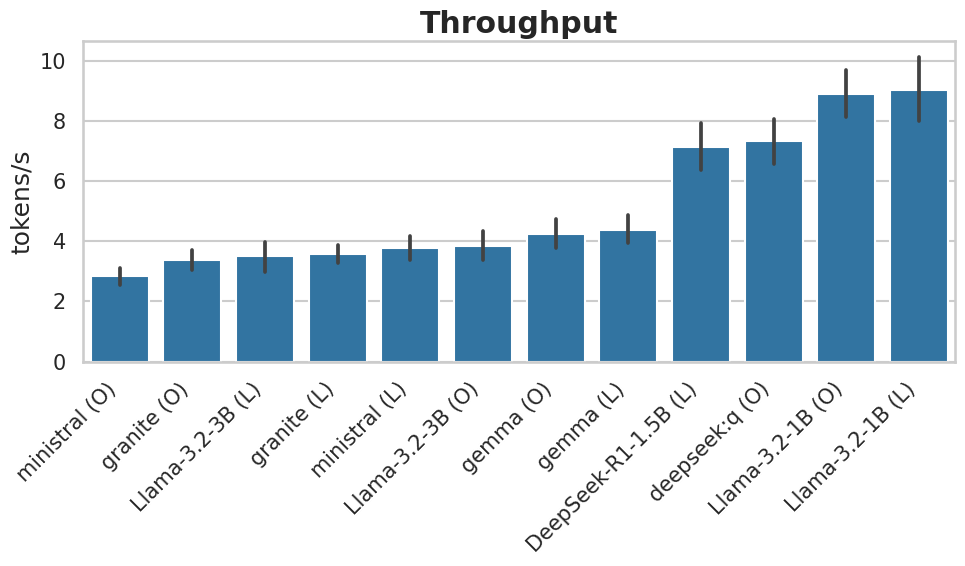

In [8]:
# Inference metrics
def _plot_metric(df, metric, ylabel, title, unit_label=""):
    data = df.dropna(subset=[metric]).copy()
    if data.empty:
        print(f"Sin datos para {metric}")
        return
    fig, ax = plt.subplots(figsize=(10, 6))
    order = data.groupby("model_label")[metric].mean().sort_values().index
    sns.barplot(data=data, x="model_label", y=metric, order=order, ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.set_title(title)
    fig.tight_layout()
    plt.show()

pm_valid = pm_full[(pm_full["run_id"].isin(ex["run_id"])) & (~pm_full["is_empty_generation"]) & (pm_full["latency_ms"] > 0)]
if not pm_valid.empty:
    _plot_metric(pm_valid, "tokens_per_second", "tokens/s", "Throughput")
else:
    print("Sin datos de inferencia")

## Alertas y anomalías

In [9]:
# Alerts
alerts = []
throttled = ex[ex["throttled_ratio"] > 0.5]
if not throttled.empty:
    for _, row in throttled.iterrows():
        alerts.append(f"⚠️  {row['model_label']}: {row['throttled_ratio']*100:.1f}% throttling")
if alerts:
    for a in alerts:
        print(a)
else:
    print("✅ Sin alertas detectadas")

⚠️  ministral (O): 99.3% throttling
⚠️  ministral (L): 99.8% throttling
⚠️  Llama-3.2-3B (O): 99.0% throttling
⚠️  Llama-3.2-3B (L): 100.0% throttling
⚠️  Llama-3.2-1B (O): 98.7% throttling
⚠️  Llama-3.2-1B (L): 99.9% throttling
⚠️  granite (O): 99.0% throttling
⚠️  granite (L): 99.8% throttling
⚠️  gemma (O): 98.6% throttling
⚠️  gemma (L): 99.8% throttling
⚠️  deepseek:q (O): 99.4% throttling
⚠️  DeepSeek-R1-1.5B (L): 100.0% throttling


## Timelines ampliados

Análisis temporal completo de temperatura, potencia, CPU y swap.

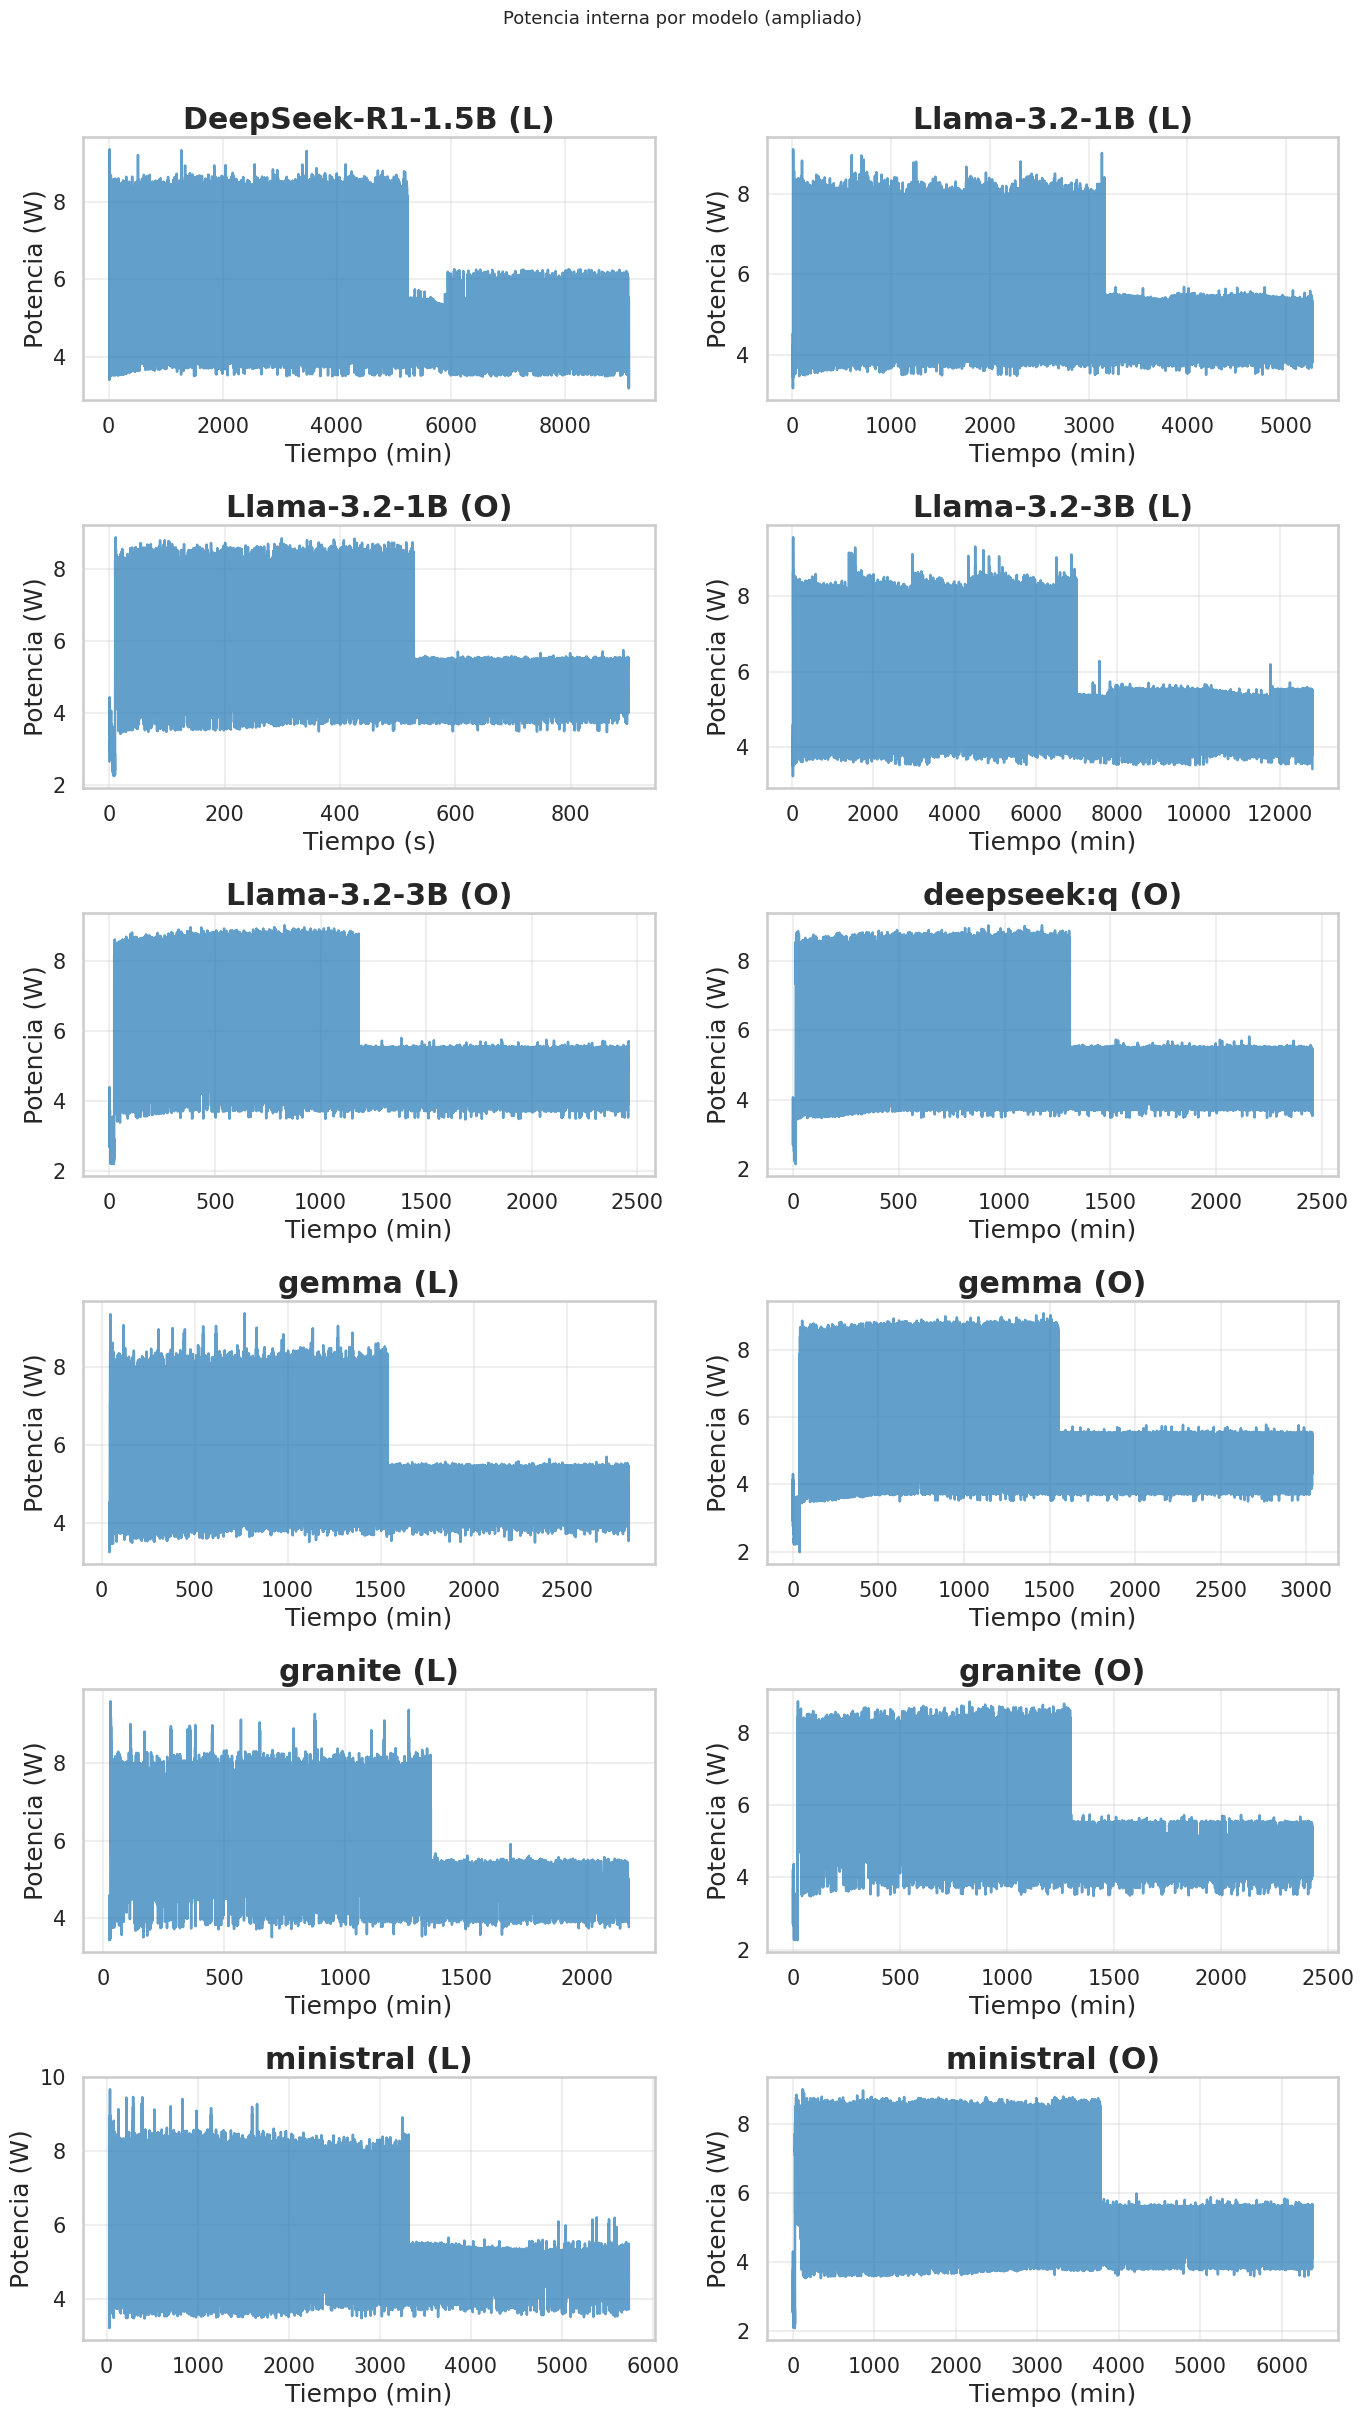

In [10]:
# Power timeline (complete section)
if not hw_ex.empty:
    models = sorted(ex["model_label"].unique())
    ncols = 2
    nrows = (len(models) + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4*nrows))
    if len(models) == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for ax, model in zip(axes, models):
        hw_m = hw_ex[hw_ex["model_label"] == model]
        if hw_m.empty:
            ax.text(0.5, 0.5, f"{model}\nSin datos", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
            continue
        sns.lineplot(data=hw_m, x="t_rel_s", y="internal_power_w", ax=ax, alpha=0.7)
        total_s = hw_m["t_rel_s"].max()
        ax.set_xlabel("Tiempo (min)" if total_s > 1800 else "Tiempo (s)")
        ax.set_ylabel("Potencia (W)")
        ax.set_title(f"{model}", fontweight="bold")
        ax.grid(True, alpha=0.3)

    for ax in axes[len(models):]:
        ax.set_visible(False)

    fig.suptitle("Potencia interna por modelo (ampliado)", fontsize=13, y=1.01)
    fig.tight_layout()
    plt.show()

## Distribución detallada CPU y Memoria

Violin plots con strip para mejor visualización.

/tmp/ipykernel_21110/2211108465.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_21110/2211108465.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


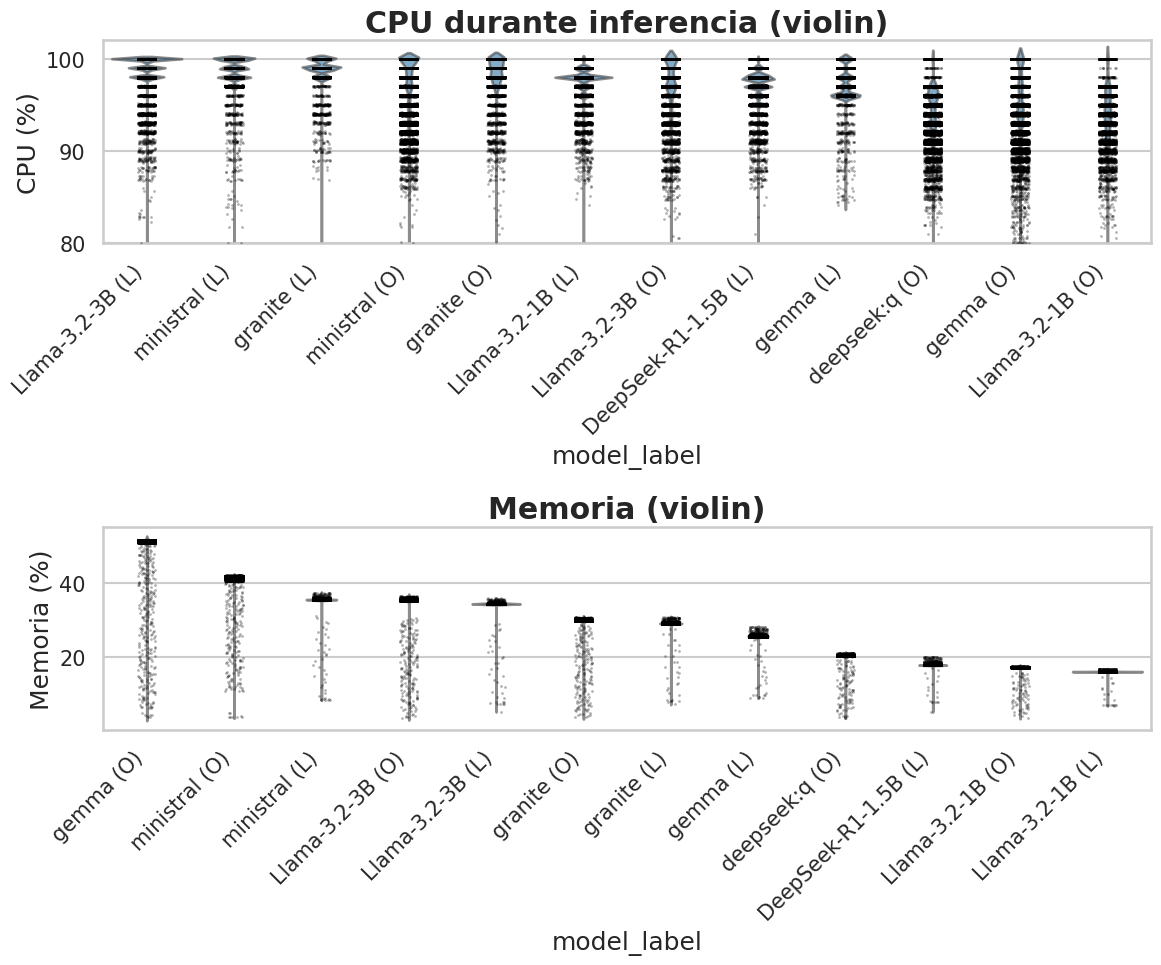

In [11]:
# Violin + strip version (with FIX rotation=45)
if not hw_ex.empty:
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))

    active = hw_ex[hw_ex["cpu_usage_pct"] > 50]
    order_cpu = active.groupby("model_label")["cpu_usage_pct"].median().sort_values(ascending=False).index if not active.empty else []

    if len(order_cpu) > 0:
        sns.violinplot(data=active, x="model_label", y="cpu_usage_pct", order=order_cpu, inner=None, alpha=0.6, ax=axes[0])
        sns.stripplot(data=active, x="model_label", y="cpu_usage_pct", order=order_cpu, size=2, alpha=0.3, color="black", ax=axes[0])
        axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
        axes[0].set_title("CPU durante inferencia (violin)")
        axes[0].set_ylabel("CPU (%)")
        axes[0].set_ylim(80, 102)

    order_mem = hw_ex.groupby("model_label")["mem_pct"].median().sort_values(ascending=False).index
    sns.violinplot(data=hw_ex, x="model_label", y="mem_pct", order=order_mem, inner=None, alpha=0.6, ax=axes[1])
    sns.stripplot(data=hw_ex, x="model_label", y="mem_pct", order=order_mem, size=2, alpha=0.3, color="black", ax=axes[1])
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
    axes[1].set_title("Memoria (violin)")
    axes[1].set_ylabel("Memoria (%)")

    fig.tight_layout()
    plt.show()

## Análisis detallado con funciones compostas

Visualizaciones complejas para un run representativo.

In [12]:
# Use composite plotting functions
try:
    from monitorviz.viz import temp_freq_dual, cpu_memory_dual_phases, hw_distributions_panel

    if not hw_ex.empty and len(ex) > 0:
        run_durations = hw_ex.groupby("run_id")["t_rel_s"].max()
        if len(run_durations) > 0:
            median_idx = len(run_durations) // 2
            representative_run_id = run_durations.iloc[median_idx]

            representative_run = None
            for r in coll.runs:
                if r.run_id == representative_run_id:
                    representative_run = r
                    break

            if representative_run:
                hw_r = hw_ex[hw_ex["run_id"] == representative_run_id]

                try:
                    fig = temp_freq_dual(hw_r, representative_run)
                    plt.show()
                except Exception as e:
                    print(f"No se pudo generar temp_freq_dual: {e}")

                try:
                    fig = cpu_memory_dual_phases(hw_r, representative_run)
                    plt.show()
                except Exception as e:
                    print(f"No se pudo generar cpu_memory_dual_phases: {e}")
except Exception as e:
    print(f"Error en análisis detallado: {e}")

## Análisis energético completo

Energía por token, MBU, trade-offs Pareto.

/tmp/ipykernel_21110/663854845.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


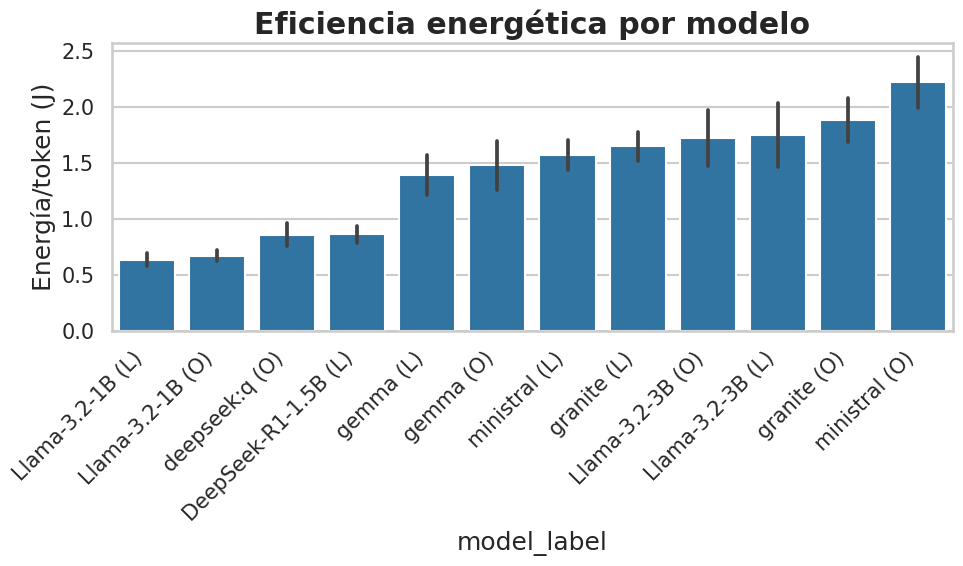

/tmp/ipykernel_21110/663854845.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


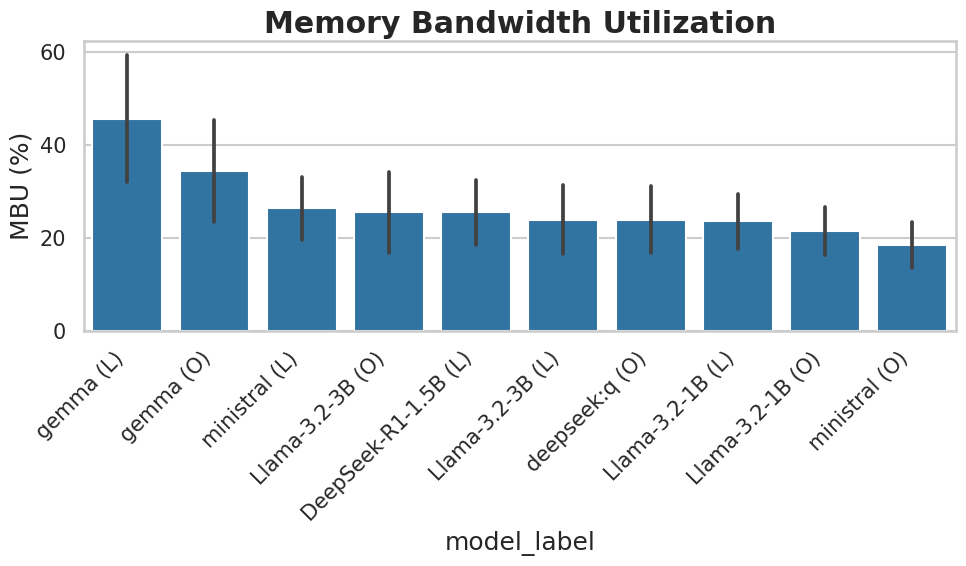

In [13]:
# Energy and efficiency analysis
if "energy_per_token_j" in ex.columns:
    energy_data = ex.dropna(subset=["energy_per_token_j"])
    if not energy_data.empty:
        fig, ax = plt.subplots(figsize=(10, 6))
        order = energy_data.groupby("model_label")["energy_per_token_j"].mean().sort_values().index
        sns.barplot(data=energy_data, x="model_label", y="energy_per_token_j", order=order, ax=ax)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_ylabel("Energía/token (J)")
        ax.set_title("Eficiencia energética por modelo")
        fig.tight_layout()
        plt.show()

# MBU analysis
if "mbu_pct" in ex.columns:
    mbu_data = ex.dropna(subset=["mbu_pct"])
    if not mbu_data.empty:
        fig, ax = plt.subplots(figsize=(10, 6))
        order = mbu_data.groupby("model_label")["mbu_pct"].mean().sort_values(ascending=False).index
        sns.barplot(data=mbu_data, x="model_label", y="mbu_pct", order=order, ax=ax)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_ylabel("MBU (%)")
        ax.set_title("Memory Bandwidth Utilization")
        fig.tight_layout()
        plt.show()

## Análisis multidimensional

Diagramas polares y correlación de Pearson.

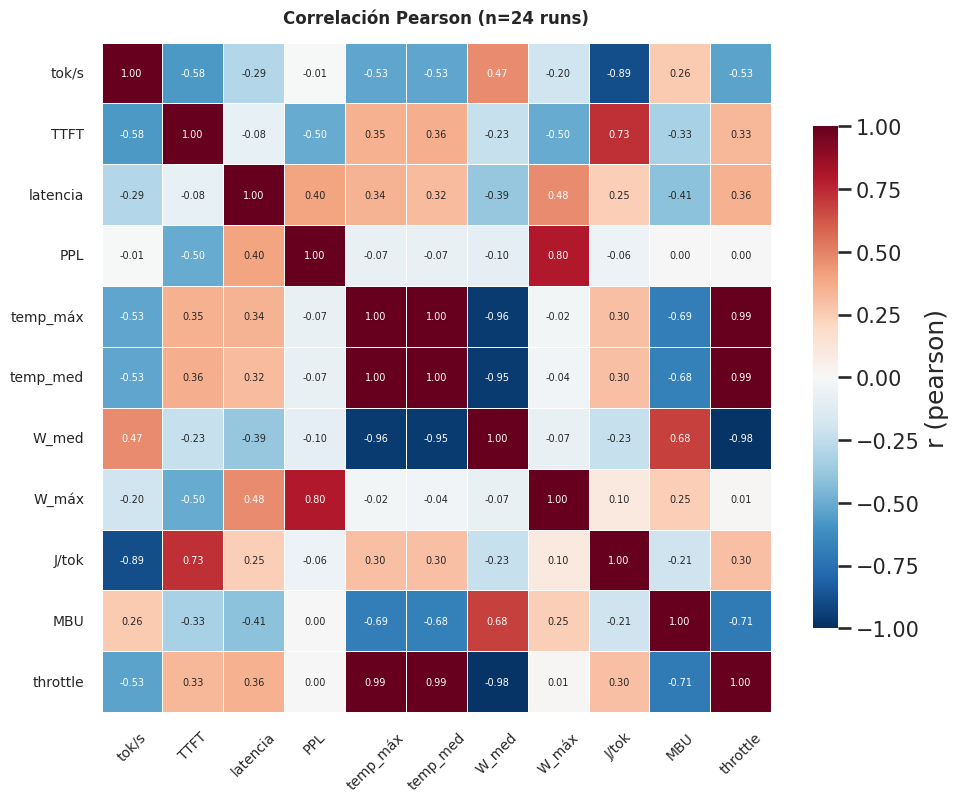

In [14]:
# Radar charts and correlation
try:
    from monitorviz.viz import correlation_heatmap

    if len(ex) >= 3:
        fig = correlation_heatmap(ex, title=f"Correlación Pearson (n={len(ex)} runs)")
        plt.show()
except Exception as e:
    print(f"Error en correlación: {e}")

## Conclusiones

> TODO: Actualizar con resultados finales.